In [1]:
import matplotlib.pyplot as plt

plt.rcParams['font.size'] = 12
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

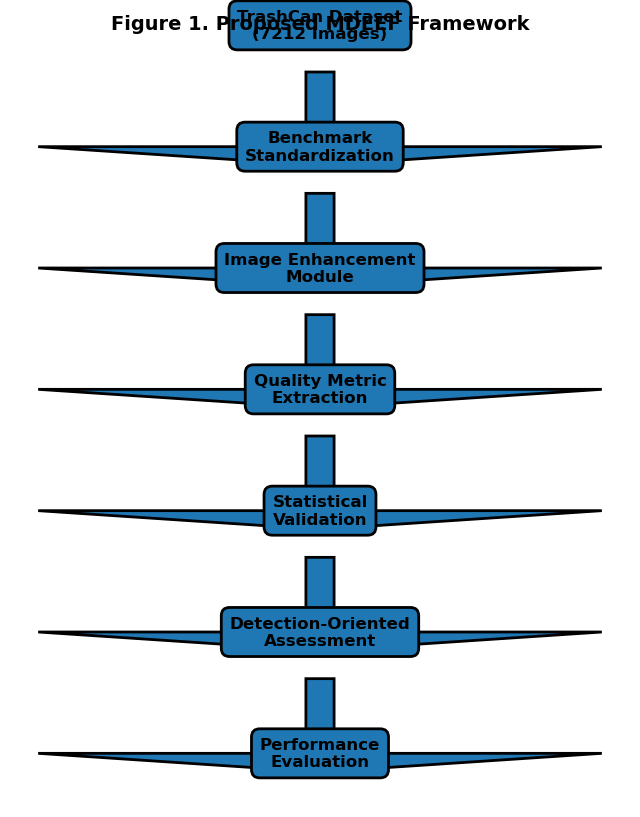

In [2]:
fig, ax = plt.subplots(figsize=(8,10))

ax.axis('off')

steps = [
    "TrashCan Dataset\n(7212 Images)",
    "Benchmark\nStandardization",
    "Image Enhancement\nModule",
    "Quality Metric\nExtraction",
    "Statistical\nValidation",
    "Detection-Oriented\nAssessment",
    "Performance\nEvaluation"
]

y = 0.9

for step in steps:

    ax.text(
        0.5,
        y,
        step,
        ha='center',
        va='center',
        fontsize=12,
        fontweight='bold',
        bbox=dict(
            boxstyle="round,pad=0.5",
            linewidth=2
        )
    )

    if y > 0.2:

        ax.arrow(
            0.5,
            y-0.05,
            0,
            -0.08,
            head_width=0.02,
            head_length=0.02,
            linewidth=2
        )

    y -= 0.13

plt.title(
    "Figure 1. Proposed MDEEF Framework",
    fontsize=14,
    fontweight='bold'
)

plt.savefig(
    "Figure1_MDEEF_Framework.png",
    dpi=600,
    bbox_inches='tight'
)

plt.show()

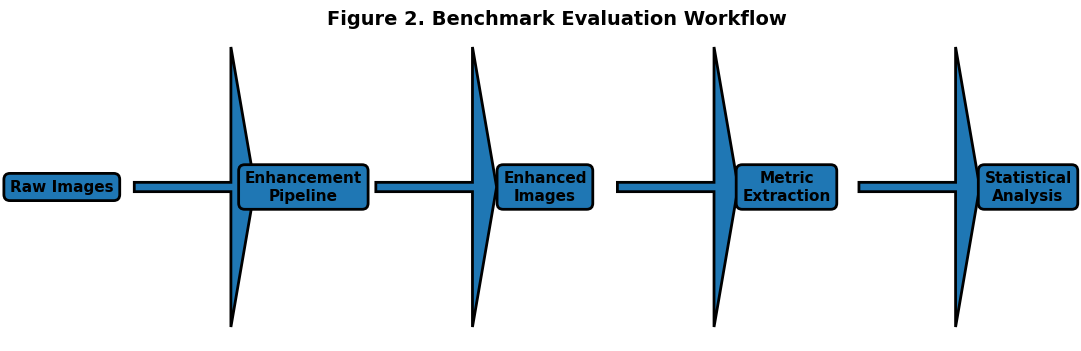

In [3]:
fig, ax = plt.subplots(figsize=(12,4))

ax.axis('off')

nodes = [

    ("Raw Images",0.1),

    ("Enhancement\nPipeline",0.3),

    ("Enhanced\nImages",0.5),

    ("Metric\nExtraction",0.7),

    ("Statistical\nAnalysis",0.9)
]

for text, x in nodes:

    ax.text(
        x,
        0.5,
        text,
        ha='center',
        va='center',
        fontsize=11,
        fontweight='bold',
        bbox=dict(
            boxstyle="round,pad=0.4",
            linewidth=2
        )
    )

for i in range(len(nodes)-1):

    ax.arrow(
        nodes[i][1]+0.06,
        0.5,
        nodes[i+1][1]-nodes[i][1]-0.12,
        0,
        head_width=0.03,
        head_length=0.02,
        linewidth=2
    )

plt.title(
    "Figure 2. Benchmark Evaluation Workflow",
    fontsize=14,
    fontweight='bold'
)

plt.savefig(
    "Figure2_Benchmark_Workflow.png",
    dpi=600,
    bbox_inches='tight'
)

plt.show()

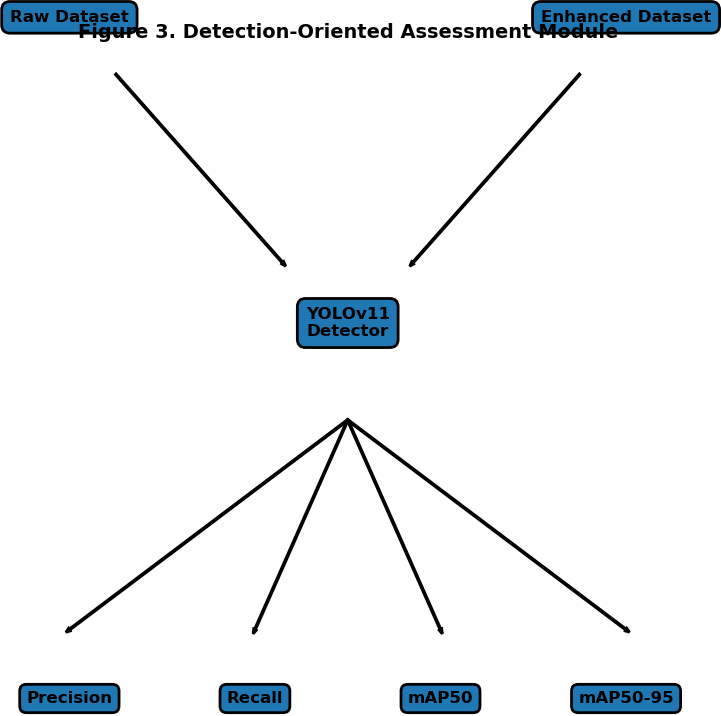

In [4]:
fig, ax = plt.subplots(figsize=(8,8))

ax.axis('off')

ax.text(
    0.2,
    0.8,
    "Raw Dataset",
    ha='center',
    bbox=dict(boxstyle="round,pad=0.5", linewidth=2)
)

ax.text(
    0.8,
    0.8,
    "Enhanced Dataset",
    ha='center',
    bbox=dict(boxstyle="round,pad=0.5", linewidth=2)
)

ax.text(
    0.5,
    0.5,
    "YOLOv11\nDetector",
    ha='center',
    bbox=dict(boxstyle="round,pad=0.5", linewidth=2)
)

metrics = [

    ("Precision",0.2),

    ("Recall",0.4),

    ("mAP50",0.6),

    ("mAP50-95",0.8)
]

for m, x in metrics:

    ax.text(
        x,
        0.15,
        m,
        ha='center',
        bbox=dict(boxstyle="round,pad=0.4", linewidth=2)
    )

ax.arrow(0.25,0.75,0.18,-0.18,linewidth=2)
ax.arrow(0.75,0.75,-0.18,-0.18,linewidth=2)

for _, x in metrics:

    ax.arrow(
        0.5,
        0.42,
        x-0.5,
        -0.20,
        linewidth=2
    )

plt.title(
    "Figure 3. Detection-Oriented Assessment Module",
    fontsize=14,
    fontweight='bold'
)

plt.savefig(
    "Figure3_Detection_Module.png",
    dpi=600,
    bbox_inches='tight'
)

plt.show()

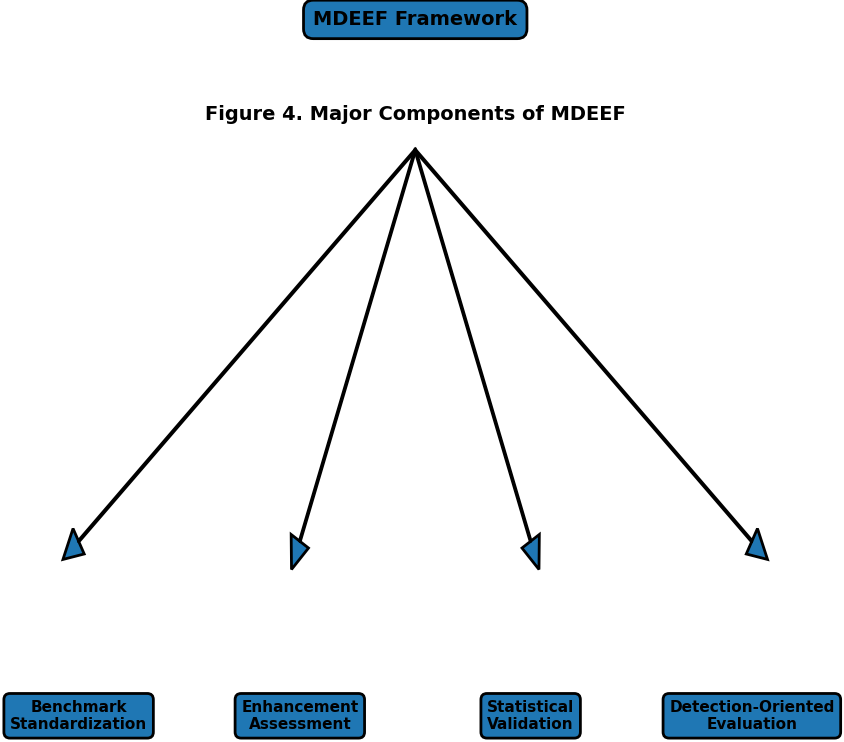

In [5]:
fig, ax = plt.subplots(figsize=(10,6))

ax.axis('off')

ax.text(
    0.5,
    0.8,
    "MDEEF Framework",
    ha='center',
    fontsize=14,
    fontweight='bold',
    bbox=dict(
        boxstyle="round,pad=0.5",
        linewidth=2
    )
)

components = [

    ("Benchmark\nStandardization",0.15),

    ("Enhancement\nAssessment",0.38),

    ("Statistical\nValidation",0.62),

    ("Detection-Oriented\nEvaluation",0.85)
]

for text, x in components:

    ax.text(
        x,
        0.35,
        text,
        ha='center',
        fontsize=11,
        fontweight='bold',
        bbox=dict(
            boxstyle="round,pad=0.4",
            linewidth=2
        )
    )

    ax.arrow(
        0.5,
        0.72,
        x-0.5,
        -0.25,
        linewidth=2,
        head_width=0.02,
        head_length=0.02
    )

plt.title(
    "Figure 4. Major Components of MDEEF",
    fontsize=14,
    fontweight='bold'
)

plt.savefig(
    "Figure4_MDEEF_Contribution.png",
    dpi=600,
    bbox_inches='tight'
)

plt.show()

In [6]:
import os
import cv2
import numpy as np
import pandas as pd

from tqdm import tqdm

from scipy.stats import ttest_rel
from scipy.stats import wilcoxon

In [7]:
raw_folder = r"E:\PHD Rahul Jain\Underwater\trashcan_data"

enhanced_folder = r"Results\enhanced_images"

In [8]:
raw_images = {}

valid_ext = (
    ".jpg",
    ".jpeg",
    ".png"
)

for root, dirs, files in os.walk(raw_folder):

    for file in files:

        if file.lower().endswith(valid_ext):

            raw_images[file] = os.path.join(
                root,
                file
            )

print("Raw Images Found:",
      len(raw_images))

Raw Images Found: 7212


In [9]:
def brightness(img):

    return np.mean(img)

def contrast(img):

    return np.std(img)

def sharpness(img):

    gray = cv2.cvtColor(
        img,
        cv2.COLOR_RGB2GRAY
    )

    return cv2.Laplacian(
        gray,
        cv2.CV_64F
    ).var()

In [10]:
raw_brightness = []
enh_brightness = []

raw_contrast = []
enh_contrast = []

raw_sharpness = []
enh_sharpness = []

In [11]:
enhanced_files = os.listdir(
    enhanced_folder
)

for file in tqdm(enhanced_files):

    if file not in raw_images:
        continue

    raw_path = raw_images[file]

    enh_path = os.path.join(
        enhanced_folder,
        file
    )

    raw_img = cv2.imread(raw_path)

    enh_img = cv2.imread(enh_path)

    if raw_img is None:
        continue

    if enh_img is None:
        continue

    raw_img = cv2.cvtColor(
        raw_img,
        cv2.COLOR_BGR2RGB
    )

    enh_img = cv2.cvtColor(
        enh_img,
        cv2.COLOR_BGR2RGB
    )

    raw_brightness.append(
        brightness(raw_img)
    )

    enh_brightness.append(
        brightness(enh_img)
    )

    raw_contrast.append(
        contrast(raw_img)
    )

    enh_contrast.append(
        contrast(enh_img)
    )

    raw_sharpness.append(
        sharpness(raw_img)
    )

    enh_sharpness.append(
        sharpness(enh_img)
    )

100%|██████████████████████████████████████████████████████████████████████████████| 7212/7212 [02:18<00:00, 52.15it/s]


In [12]:
print("===== PAIRED T-TEST =====")

t_b, p_b = ttest_rel(
    enh_brightness,
    raw_brightness
)

t_c, p_c = ttest_rel(
    enh_contrast,
    raw_contrast
)

t_s, p_s = ttest_rel(
    enh_sharpness,
    raw_sharpness
)

print("\nBrightness")

print("t =", t_b)

print("p =", p_b)

print("\nContrast")

print("t =", t_c)

print("p =", p_c)

print("\nSharpness")

print("t =", t_s)

print("p =", p_s)

===== PAIRED T-TEST =====

Brightness
t = 208.63094798166642
p = 0.0

Contrast
t = 64.64322053551737
p = 0.0

Sharpness
t = 132.34188623699774
p = 0.0


In [13]:
print("===== WILCOXON =====")

w_b, p_b2 = wilcoxon(
    enh_brightness,
    raw_brightness
)

w_c, p_c2 = wilcoxon(
    enh_contrast,
    raw_contrast
)

w_s, p_s2 = wilcoxon(
    enh_sharpness,
    raw_sharpness
)

print("\nBrightness")

print("p =", p_b2)

print("\nContrast")

print("p =", p_c2)

print("\nSharpness")

print("p =", p_s2)

===== WILCOXON =====

Brightness
p = 0.0

Contrast
p = 0.0

Sharpness
p = 0.0


In [14]:
results = pd.DataFrame({

    "Metric":[
        "Brightness",
        "Contrast",
        "Sharpness"
    ],

    "T-Test p-value":[
        p_b,
        p_c,
        p_s
    ],

    "Wilcoxon p-value":[
        p_b2,
        p_c2,
        p_s2
    ]
})

results

,Metric,T-Test p-value,Wilcoxon p-value
0,Brightness,0.0,0.0
1,Contrast,0.0,0.0
2,Sharpness,0.0,0.0


In [15]:
import pandas as pd
import numpy as np

summary = pd.DataFrame({

    "Metric":[
        "Brightness",
        "Contrast",
        "Sharpness"
    ],

    "Raw Mean":[
        np.mean(raw_brightness),
        np.mean(raw_contrast),
        np.mean(raw_sharpness)
    ],

    "Enhanced Mean":[
        np.mean(enh_brightness),
        np.mean(enh_contrast),
        np.mean(enh_sharpness)
    ]
})

summary["Improvement (%)"] = (
    (summary["Enhanced Mean"]
     - summary["Raw Mean"])
    /
    summary["Raw Mean"]
) * 100

summary

,Metric,Raw Mean,Enhanced Mean,Improvement (%)
0,Brightness,94.166121,113.206264,20.219738
1,Contrast,40.017017,47.013189,17.482991
2,Sharpness,1968.659020,14649.992210,644.160978


In [16]:
import pandas as pd

df = pd.read_csv(
    "Results/metrics/mdeef_dataset_metrics.csv"
)

df["Sharpness_Gain"] = (
    df["Enhanced_Sharpness"]
    -
    df["Raw_Sharpness"]
)

df.sort_values(
    by="Sharpness_Gain",
    ascending=False,
    inplace=True
)

df.head(20)

KeyError: 'Enhanced_Sharpness'

In [17]:
import pandas as pd

df = pd.read_csv(
    "Results/metrics/mdeef_dataset_metrics.csv"
)

print(df.columns.tolist())

['image_name', 'brightness', 'contrast', 'sharpness']


In [18]:
import os
import cv2
import numpy as np
import pandas as pd

from tqdm import tqdm

In [19]:
def brightness(img):

    return np.mean(img)

def contrast(img):

    return np.std(img)

def sharpness(img):

    gray = cv2.cvtColor(
        img,
        cv2.COLOR_RGB2GRAY
    )

    return cv2.Laplacian(
        gray,
        cv2.CV_64F
    ).var()

In [20]:
raw_root = r"E:\PHD Rahul Jain\Underwater\trashcan_data"

enhanced_root = r"Results\enhanced_images"

In [21]:
raw_dict = {}

for root, dirs, files in os.walk(raw_root):

    for file in files:

        if file.lower().endswith(
            (".jpg",".jpeg",".png")
        ):

            raw_dict[file] = os.path.join(
                root,
                file
            )

print(
    "Raw Images:",
    len(raw_dict)
)

Raw Images: 7212


In [22]:
results = []

enhanced_files = os.listdir(
    enhanced_root
)

for file in tqdm(enhanced_files):

    if file not in raw_dict:
        continue

    raw_path = raw_dict[file]

    enh_path = os.path.join(
        enhanced_root,
        file
    )

    raw_img = cv2.imread(raw_path)

    enh_img = cv2.imread(enh_path)

    if raw_img is None:
        continue

    if enh_img is None:
        continue

    raw_img = cv2.cvtColor(
        raw_img,
        cv2.COLOR_BGR2RGB
    )

    enh_img = cv2.cvtColor(
        enh_img,
        cv2.COLOR_BGR2RGB
    )

    results.append({

        "image_name":file,

        "raw_brightness":
            brightness(raw_img),

        "enhanced_brightness":
            brightness(enh_img),

        "raw_contrast":
            contrast(raw_img),

        "enhanced_contrast":
            contrast(enh_img),

        "raw_sharpness":
            sharpness(raw_img),

        "enhanced_sharpness":
            sharpness(enh_img)
    })

100%|█████████████████████████████████████████████████████████████████████████████| 7212/7212 [00:52<00:00, 136.09it/s]


In [23]:
comparison_df = pd.DataFrame(
    results
)

comparison_df.to_csv(

    "Results/metrics/mdeef_comparison_metrics.csv",

    index=False
)

print(
    comparison_df.shape
)

(7212, 7)


In [24]:
df = pd.read_csv(
    "Results/metrics/mdeef_comparison_metrics.csv"
)

df["Sharpness_Gain"] = (
    df["enhanced_sharpness"]
    -
    df["raw_sharpness"]
)

df.sort_values(
    by="Sharpness_Gain",
    ascending=False
).head(10)

,image_name,raw_brightness,enhanced_brightness,raw_contrast,enhanced_contrast,raw_sharpness,enhanced_sharpness,Sharpness_Gain
1263,vid_000090_frame0000030.jpg,99.932155,122.000712,29.235006,74.184927,4026.852227,70474.397857,66447.545631
1380,vid_000102_frame0000035.jpg,95.226703,114.159505,42.409033,72.935302,6270.340238,70584.249133,64313.908895
1262,vid_000090_frame0000018.jpg,100.486646,122.460983,29.336756,73.533978,3731.471319,66535.502677,62804.031358
1318,vid_000095_frame0000012.jpg,88.314547,122.247492,45.155856,76.345334,4201.280961,63976.521323,59775.240362
1430,vid_000105_frame0000004.jpg,54.668654,79.143819,43.494378,74.742668,2670.101748,59986.714735,57316.612987
1319,vid_000095_frame0000019.jpg,88.500635,121.507497,45.007841,75.321293,4016.312205,61279.883095,57263.570891
1452,vid_000105_frame0000044.jpg,59.832303,81.075150,47.512427,75.781898,2622.271461,59335.909951,56713.638490
1431,vid_000105_frame0000005.jpg,54.906042,79.451828,43.628682,74.497278,2655.222494,58531.471858,55876.249364
6971,vid_000532_frame0000044.jpg,97.860466,126.697861,40.756849,70.504779,4800.925594,60175.639085,55374.713492
6968,vid_000532_frame0000041.jpg,98.195530,127.815628,36.993172,66.263165,4863.464732,60227.379655,55363.914924


In [25]:
df.sort_values(
    by="Sharpness_Gain",
    ascending=True
).head(10)

,image_name,raw_brightness,enhanced_brightness,raw_contrast,enhanced_contrast,raw_sharpness,enhanced_sharpness,Sharpness_Gain
4200,vid_000263_frame0000016.jpg,215.280627,206.304876,32.460146,36.970389,1077.387083,2800.304395,1722.917312
4437,vid_000271_frame0000046.jpg,182.536420,179.989583,53.120852,36.581152,855.373884,2658.973588,1803.599704
4436,vid_000271_frame0000045.jpg,183.411834,180.417267,53.371889,36.998841,840.346503,2818.630420,1978.283918
6410,vid_000427_frame0000031.jpg,138.433152,158.901301,25.598488,23.987308,55.449245,2360.815827,2305.366582
4439,vid_000271_frame0000048.jpg,181.284686,178.492360,53.068914,37.024737,844.837134,3178.574681,2333.737547
4198,vid_000263_frame0000014.jpg,211.146059,207.124044,33.726054,33.366140,904.550485,3259.128846,2354.578362
4435,vid_000271_frame0000044.jpg,182.391069,178.507935,53.479251,35.526275,800.089828,3186.983617,2386.893789
6411,vid_000427_frame0000033.jpg,115.891584,137.468424,24.420663,23.205719,90.132778,2526.314530,2436.181752
4438,vid_000271_frame0000047.jpg,181.039801,177.885351,53.284118,37.040587,865.540258,3430.395495,2564.855237
4440,vid_000271_frame0000049.jpg,181.896375,180.231812,52.454139,36.976761,816.011543,3462.749230,2646.737687


In [26]:
import os
import cv2
import matplotlib.pyplot as plt

best_img = "vid_000090_frame0000030.jpg"

failure_img = "vid_000263_frame0000016.jpg"

In [27]:
def find_raw_image(filename, root):

    for r, d, files in os.walk(root):

        if filename in files:

            return os.path.join(
                r,
                filename
            )

    return None

In [28]:
raw_root = r"E:\PHD Rahul Jain\Underwater\trashcan_data"

enh_root = r"Results\enhanced_images"

In [29]:
best_raw = find_raw_image(
    best_img,
    raw_root
)

best_enh = os.path.join(
    enh_root,
    best_img
)

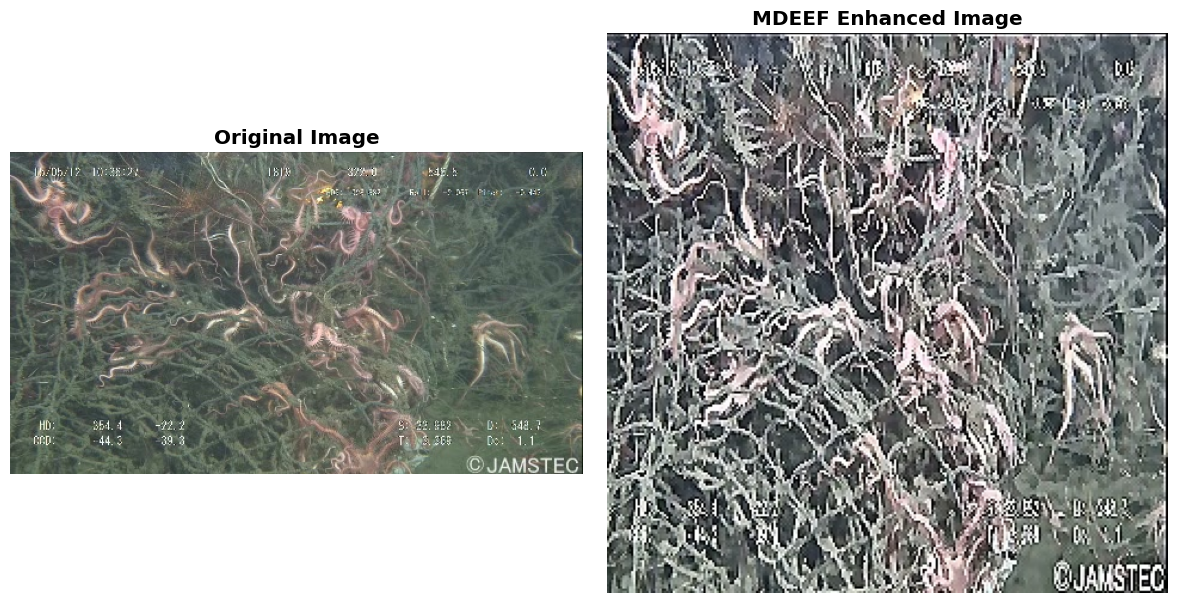

In [30]:
raw = cv2.cvtColor(
    cv2.imread(best_raw),
    cv2.COLOR_BGR2RGB
)

enh = cv2.cvtColor(
    cv2.imread(best_enh),
    cv2.COLOR_BGR2RGB
)

fig, ax = plt.subplots(
    1,
    2,
    figsize=(12,6)
)

ax[0].imshow(raw)
ax[0].set_title(
    "Original Image",
    fontweight='bold'
)
ax[0].axis("off")

ax[1].imshow(enh)
ax[1].set_title(
    "MDEEF Enhanced Image",
    fontweight='bold'
)
ax[1].axis("off")

plt.tight_layout()

plt.savefig(
    "Figure5A_Strong_Enhancement.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [31]:
df["Sharpness_Gain"].describe()

count     7212.000000
mean     12681.333189
std       8137.583392
min       1722.917312
25%       7817.132334
50%      10028.337372
75%      13935.368929
max      66447.545631
Name: Sharpness_Gain, dtype: float64

In [32]:
df.sort_values(
    by="Sharpness_Gain"
).iloc[
    len(df)//2 - 20 :
    len(df)//2 + 20
][[
    "image_name",
    "Sharpness_Gain"
]]

,image_name,Sharpness_Gain
433,vid_000040_frame0000039.jpg,9995.301711
375,vid_000038_frame0000015.jpg,9995.731769
4219,vid_000264_frame0000025.jpg,9997.857813
4823,vid_000285_frame0000076.jpg,10002.166314
4516,vid_000276_frame0000019.jpg,10003.690668
6190,vid_000362_frame0000001.jpg,10005.102111
3210,vid_000162_frame0000006.jpg,10006.256892
2090,vid_000132_frame0000015.jpg,10012.996053
7040,vid_000539_frame0000055.jpg,10013.560547
5127,vid_000291_frame0000010.jpg,10013.605380


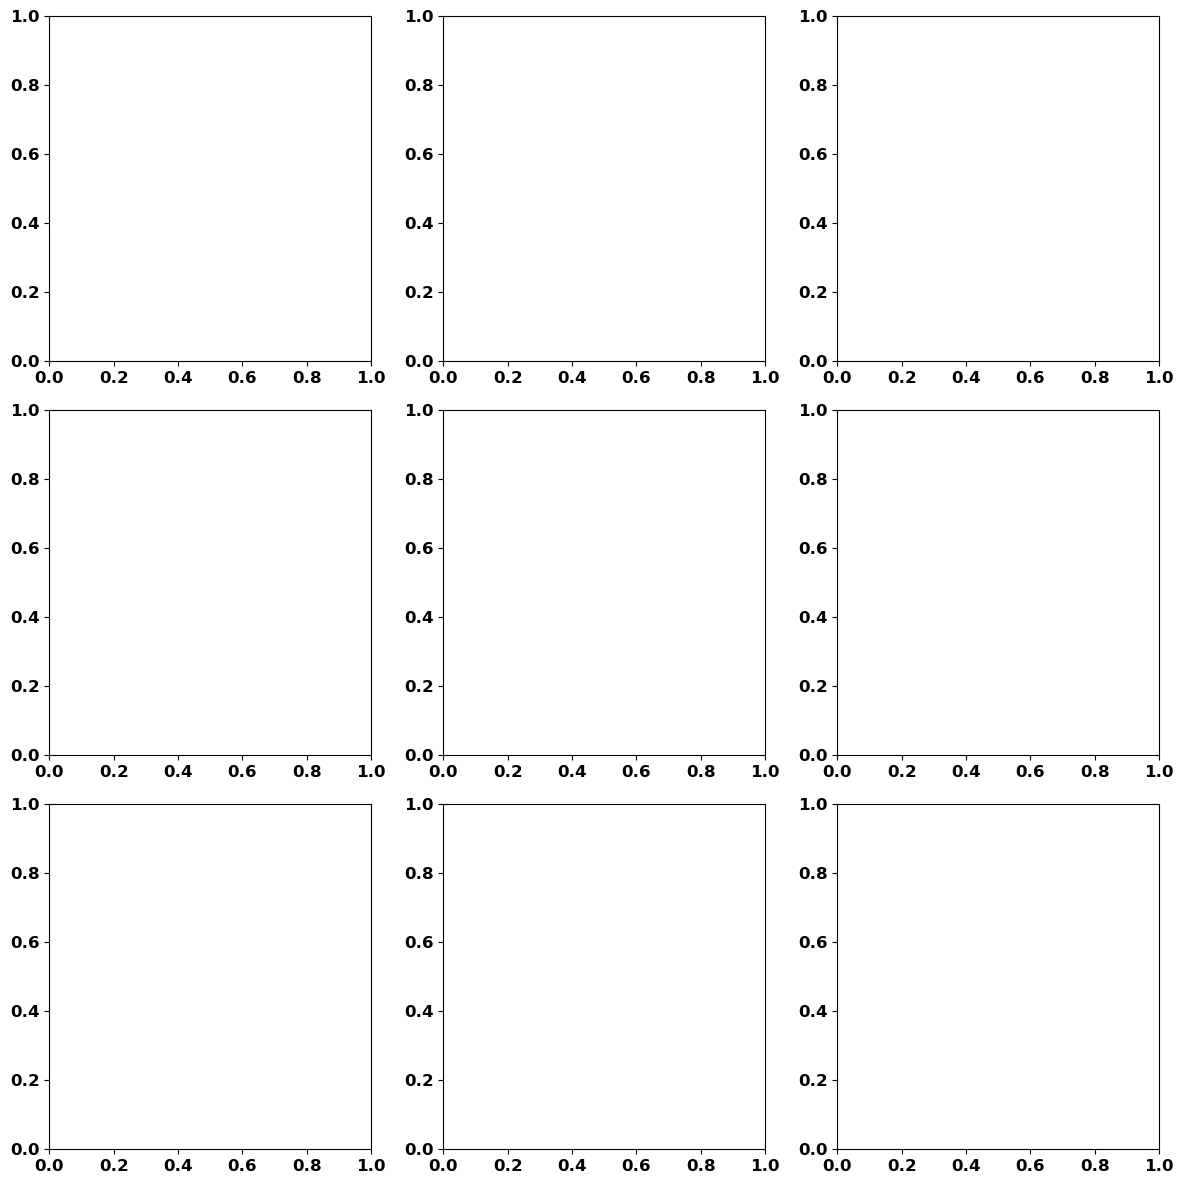

In [33]:
import os
import cv2
import matplotlib.pyplot as plt

sample_images = [
    # paste image names here
]

fig, axes = plt.subplots(
    3,
    3,
    figsize=(12,12)
)

for ax, img_name in zip(
    axes.ravel(),
    sample_images
):

    path = os.path.join(
        "Results/enhanced_images",
        img_name
    )

    img = cv2.imread(path)

    if img is None:
        continue

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    ax.imshow(img)

    ax.set_title(
        img_name[:15],
        fontsize=8
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [34]:
import os

print(os.listdir("Dataset")[:20])

['enhanced', 'metrics', 'raw']


In [35]:
print(os.listdir("Results")[:20])

['enhanced_images', 'failed_images', 'logs', 'metrics']


In [36]:
import os

target = "vid_000040_frame0000039.jpg"

for root, dirs, files in os.walk("."):

    if target in files:

        print(
            "FOUND:",
            os.path.join(root, target)
        )

FOUND: .\Results\enhanced_images\vid_000040_frame0000039.jpg
FOUND: .\YOLO_Dataset\images\val\vid_000040_frame0000039.jpg


error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


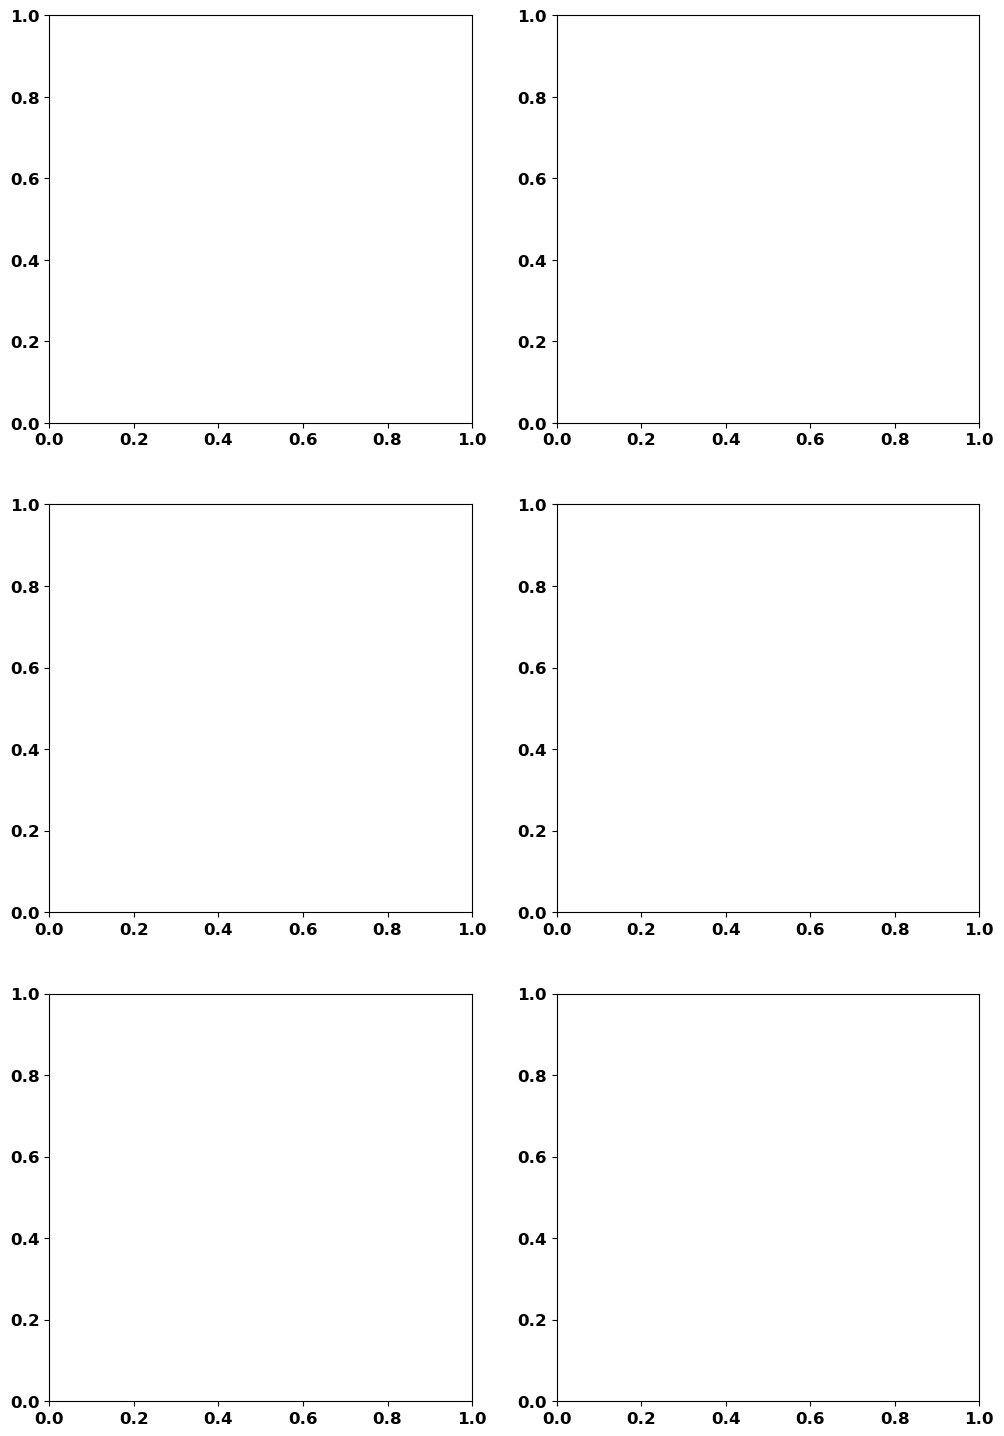

In [37]:
import os
import cv2
import matplotlib.pyplot as plt

raw_root = r"Dataset/raw"
enh_root = r"Results/enhanced_images"

images = [

    ("Strong Enhancement",
     "vid_000090_frame0000030.jpg"),

    ("Typical Enhancement",
     "vid_000040_frame0000039.jpg"),

    ("Limitation Case",
     "vid_000263_frame0000016.jpg")
]


def find_raw_image(filename):

    for root, dirs, files in os.walk(raw_root):

        if filename in files:

            return os.path.join(
                root,
                filename
            )

    return None


fig, axes = plt.subplots(
    3,
    2,
    figsize=(12,18)
)

for row, (title, img_name) in enumerate(images):

    raw_path = find_raw_image(img_name)

    enh_path = os.path.join(
        enh_root,
        img_name
    )

    raw_img = cv2.cvtColor(
        cv2.imread(raw_path),
        cv2.COLOR_BGR2RGB
    )

    enh_img = cv2.cvtColor(
        cv2.imread(enh_path),
        cv2.COLOR_BGR2RGB
    )

    axes[row,0].imshow(raw_img)
    axes[row,0].set_title(
        f"{title}\nOriginal",
        fontweight="bold"
    )
    axes[row,0].axis("off")

    axes[row,1].imshow(enh_img)
    axes[row,1].set_title(
        f"{title}\nEnhanced",
        fontweight="bold"
    )
    axes[row,1].axis("off")

plt.tight_layout()

plt.savefig(
    "Figure5_MDEEF_Visual_Analysis.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()